In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("./../base_dados.xlsx")
df.columns = (
    df.columns
    .str.lower()
    .str.normalize('NFKD')
    .str.encode('ascii', errors='ignore')
    .str.decode('utf-8')
    .str.replace(' ', '_')
)
df.head()

,ra,fase,turma,nome,ano_nasc,idade_22,genero,ano_ingresso,instituicao_de_ensino,pedra_20,...,ingles,indicado,atingiu_pv,ipv,ian,fase_ideal,defas,destaque_ieg,destaque_ida,destaque_ipv
0,RA-1,7,A,Aluno-1,2003,19,Menina,2016,Escola Pública,Ametista,...,6.0,Sim,Não,7.278,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
1,RA-2,7,A,Aluno-2,2005,17,Menina,2017,Rede Decisão,Ametista,...,9.7,Não,Não,6.778,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
2,RA-3,7,A,Aluno-3,2005,17,Menina,2016,Rede Decisão,Ametista,...,6.9,Não,Não,7.556,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...
3,RA-4,7,A,Aluno-4,2005,17,Menino,2017,Rede Decisão,Ametista,...,8.7,Não,Não,5.278,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
4,RA-5,7,A,Aluno-5,2005,17,Menina,2016,Rede Decisão,Ametista,...,5.7,Não,Não,7.389,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...


In [2]:
# Criar coluna target
df["target"] = (df["defas"] < 0).astype(int)

# Transformar textos das colunas 'destaque_ieg', 'destaque_ida' e 'destaque_ipv' em classes
df["destaque_ieg"] = df["destaque_ieg"].str.contains("Destaque").astype(int)
df["destaque_ida"] = df["destaque_ida"].str.contains("Destaque").astype(int)
df["destaque_ipv"] = df["destaque_ipv"].str.contains("Destaque").astype(int)

# Remover colunas redundantes
df = df.drop(columns=['ano_nasc', 'nome'])
# Remover colunas que respondem a pergunta do modelo
df = df.drop(columns=['defas', 'fase_ideal'])
# Remover colunas que não influenciam o modelo
df = df.drop(columns=['avaliador1', 'avaliador2', 'avaliador3', 'avaliador4'])

df.columns

Index(['ra', 'fase', 'turma', 'idade_22', 'genero', 'ano_ingresso',
       'instituicao_de_ensino', 'pedra_20', 'pedra_21', 'pedra_22', 'inde_22',
       'cg', 'cf', 'ct', 'no_av', 'rec_av1', 'rec_av2', 'rec_av3', 'rec_av4',
       'iaa', 'ieg', 'ips', 'rec_psicologia', 'ida', 'matem', 'portug',
       'ingles', 'indicado', 'atingiu_pv', 'ipv', 'ian', 'destaque_ieg',
       'destaque_ida', 'destaque_ipv', 'target'],
      dtype='str')

C:\Users\vitor\AppData\Local\Temp\ipykernel_12196\3091622693.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns.tolist()


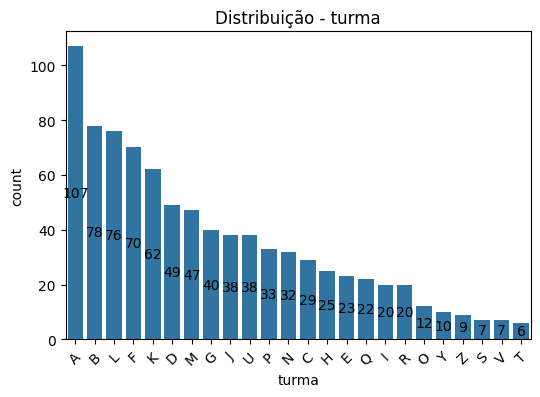

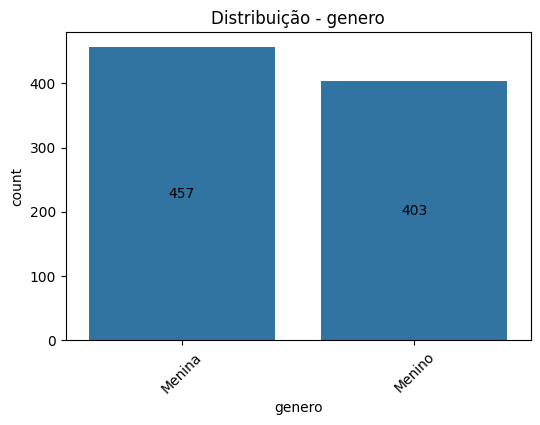

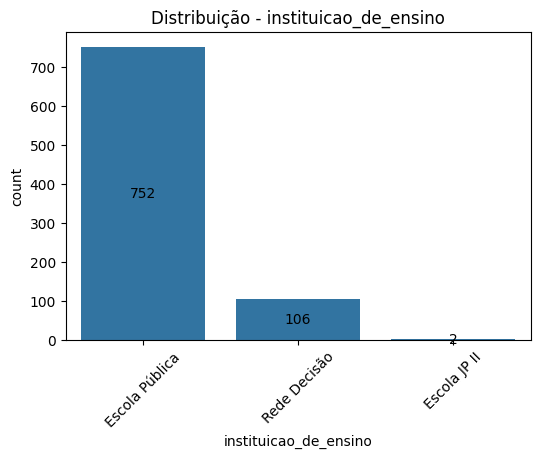

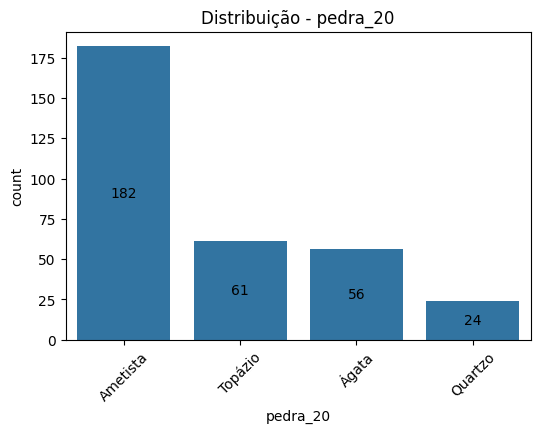

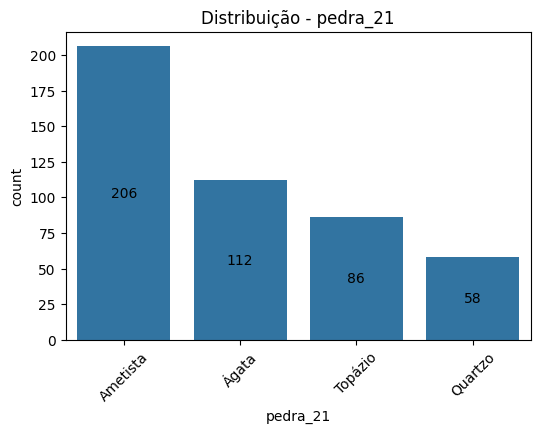

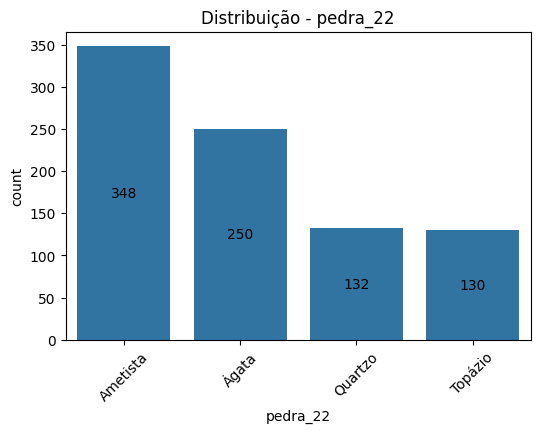

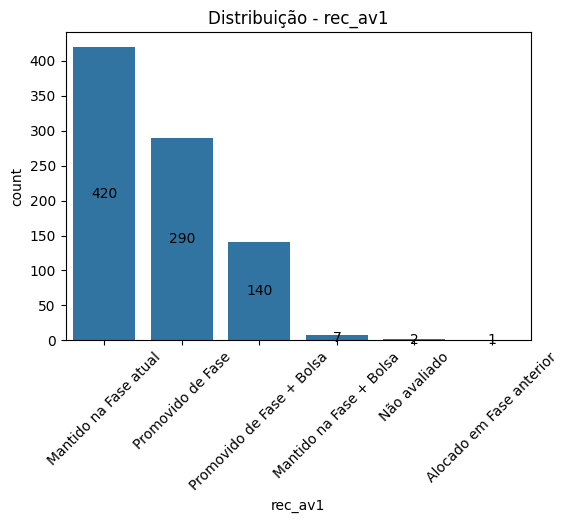

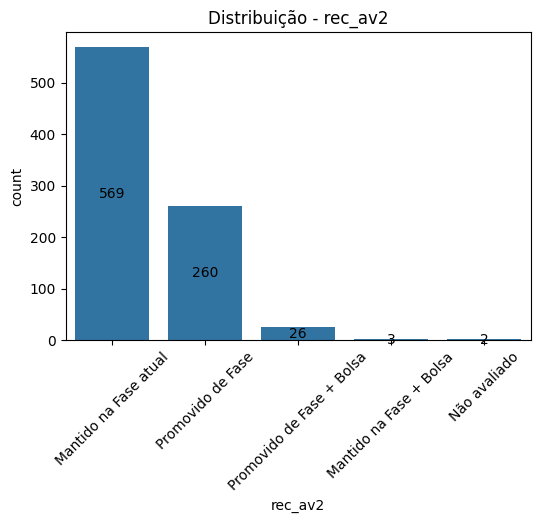

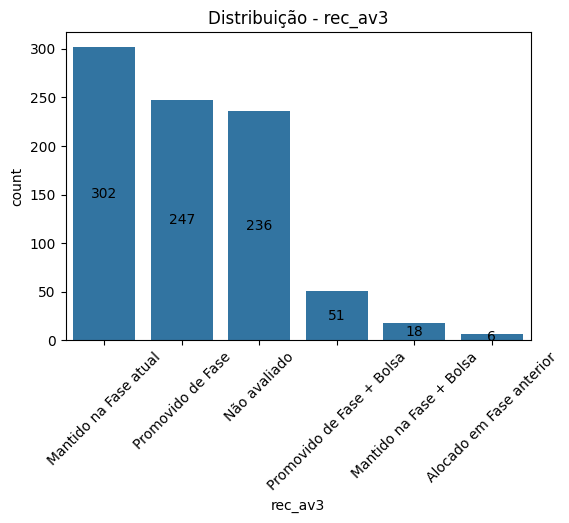

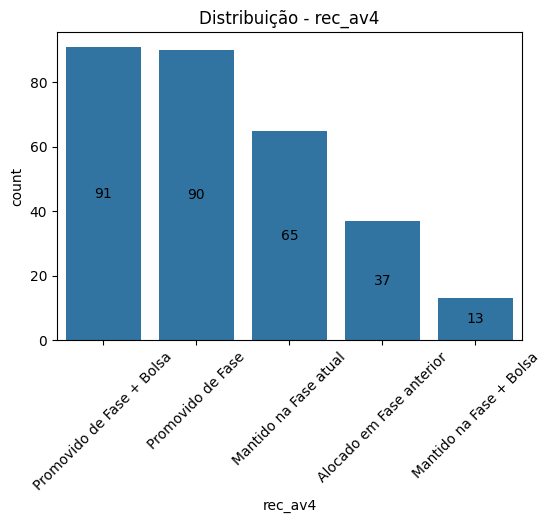

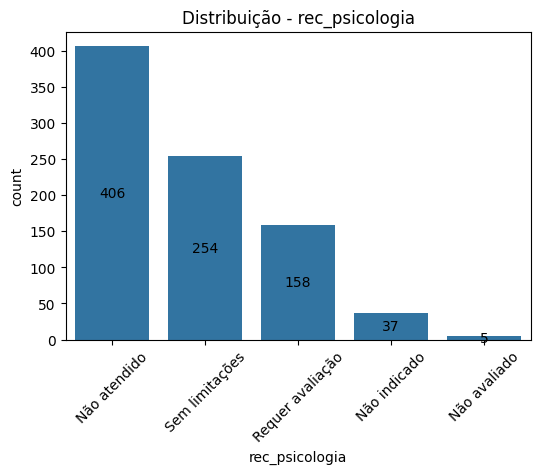

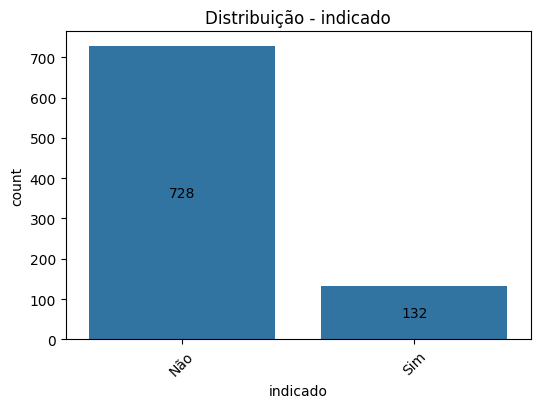

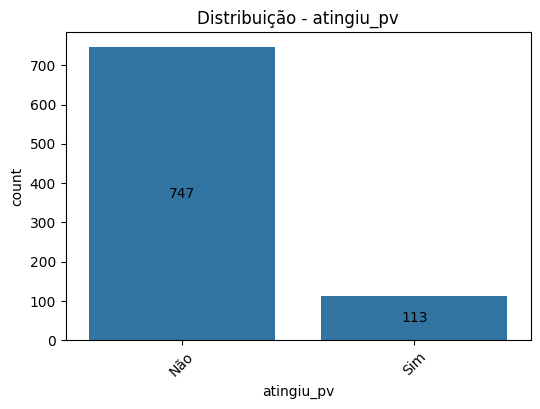

In [3]:
# Analisar colunas com categorias de baixo N 
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
cat_cols.remove("ra")

for col in cat_cols:
    
    plt.figure(figsize=(6,4))
    
    ax = sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )
    
    plt.title(f"Distribuição - {col}")
    plt.xticks(rotation=45)

    # adicionar valores dentro das barras
    for container in ax.containers:
        ax.bar_label(container, label_type="center")

    plt.show()

In [4]:
# Tratar valores de 'n' muito baixo
df["instituicao_de_ensino"] = (
    df["instituicao_de_ensino"]
    .eq("Escola Pública")
    .map({True: "escola publica", False: "escola privada"})
)

# A variável turma apresentou uma grande variedade de categorias
# Não é uma boa variável preditora
df = df.drop(columns=['turma'])

C:\Users\vitor\AppData\Local\Temp\ipykernel_12196\499432855.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns.tolist()


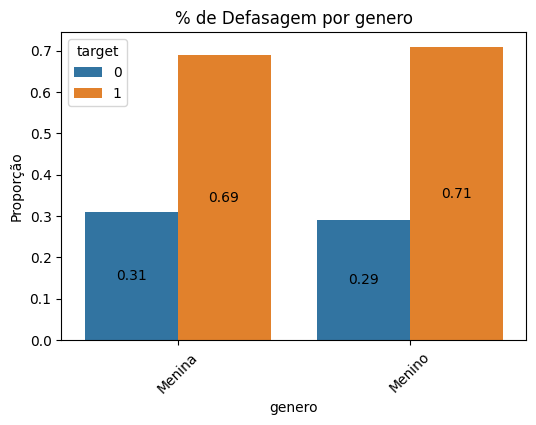

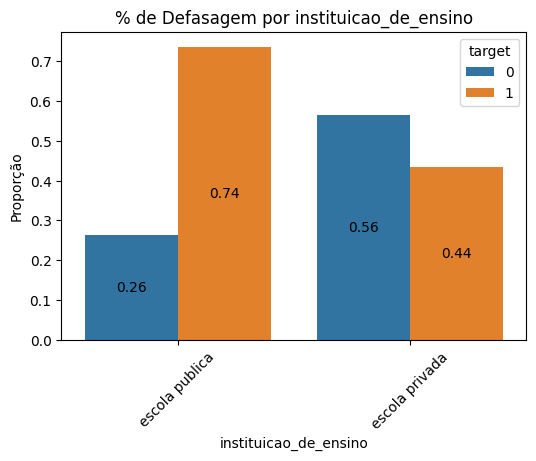

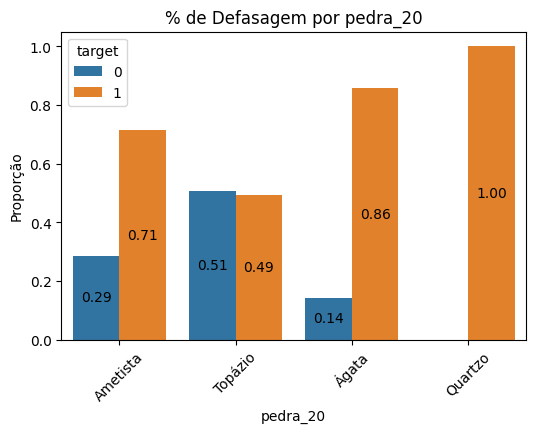

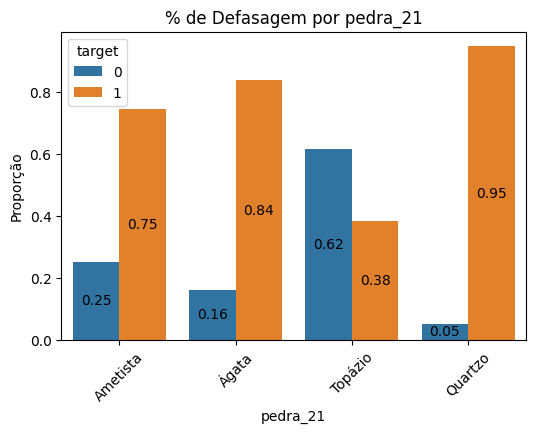

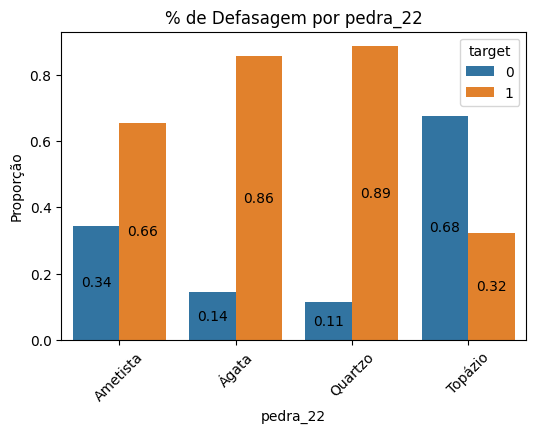

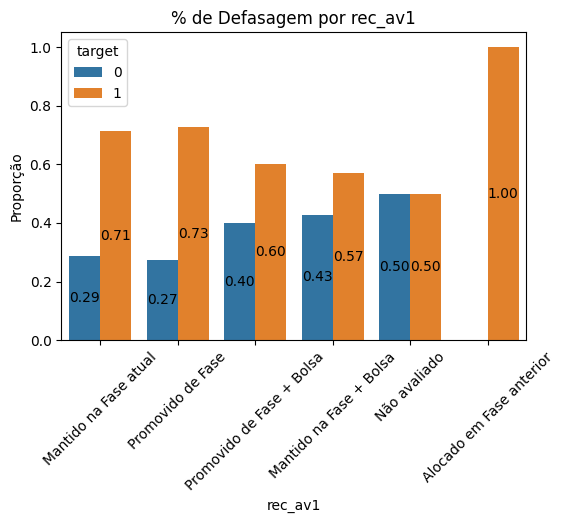

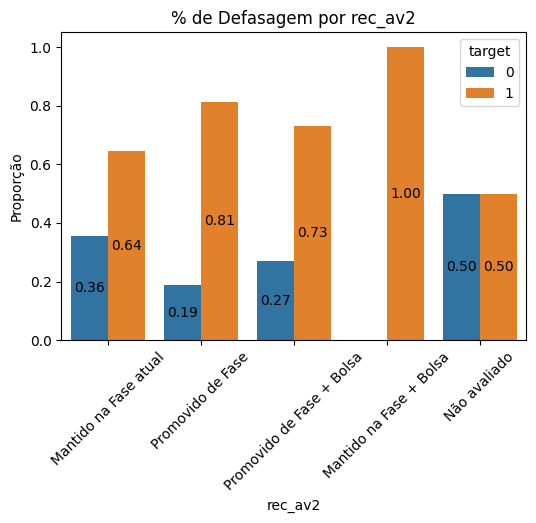

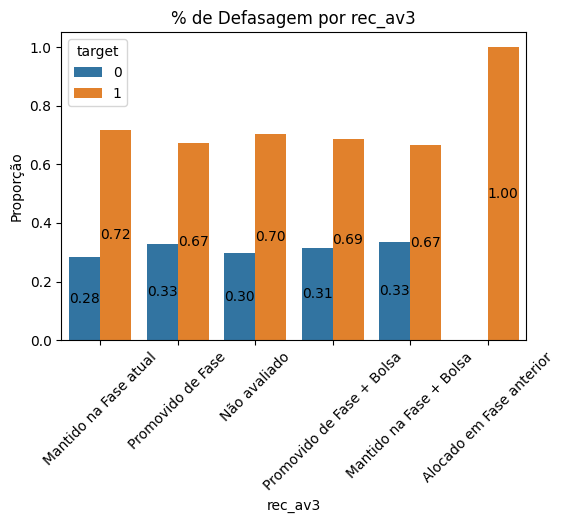

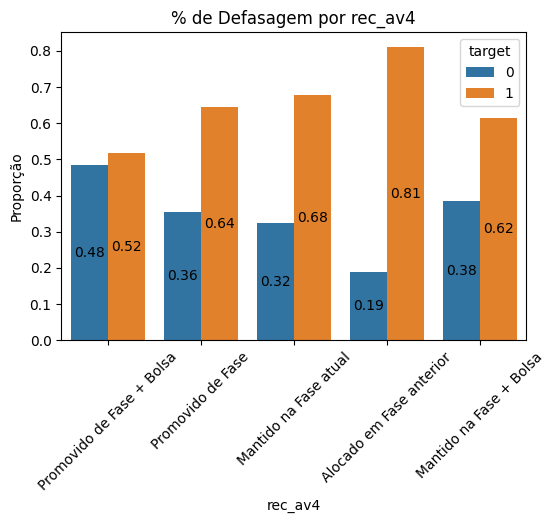

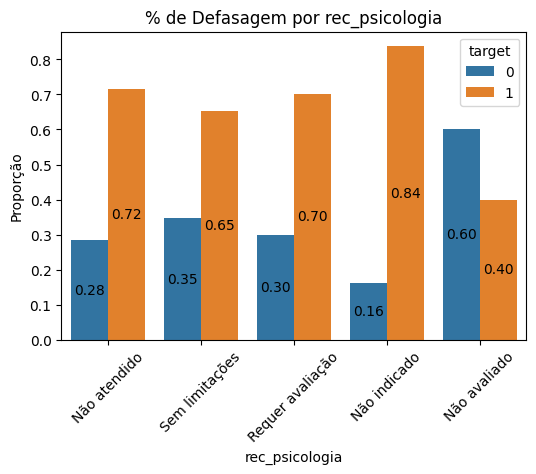

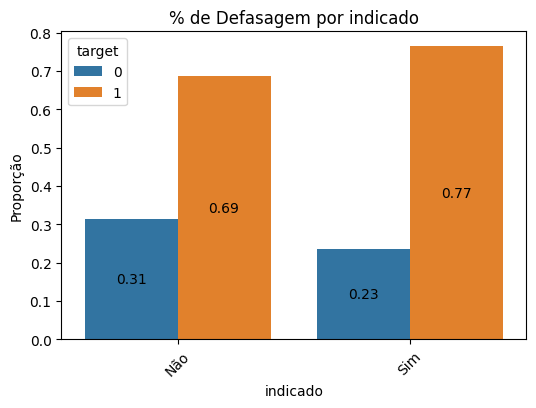

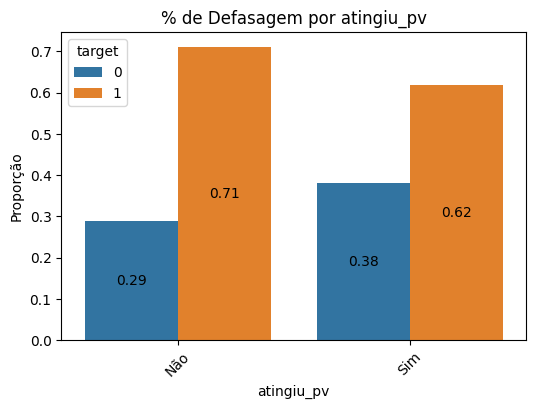

In [5]:
# Analisar diferença a defasagem de acordo com as categorias
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
cat_cols.remove("ra")

for col in cat_cols:
    
    prop = (
        df.groupby(col)["target"]
        .value_counts(normalize=True)
        .rename("proportion")
        .reset_index()
    )
    
    plt.figure(figsize=(6,4))
    
    ax = sns.barplot(
        data=prop,
        x=col,
        y="proportion",
        hue="target",
        order=df[col].value_counts().index
    )
    
    plt.title(f"% de Defasagem por {col}")
    plt.ylabel("Proporção")
    plt.xticks(rotation=45)

    # adicionar rótulo nas barras
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", label_type="center")

    plt.show()

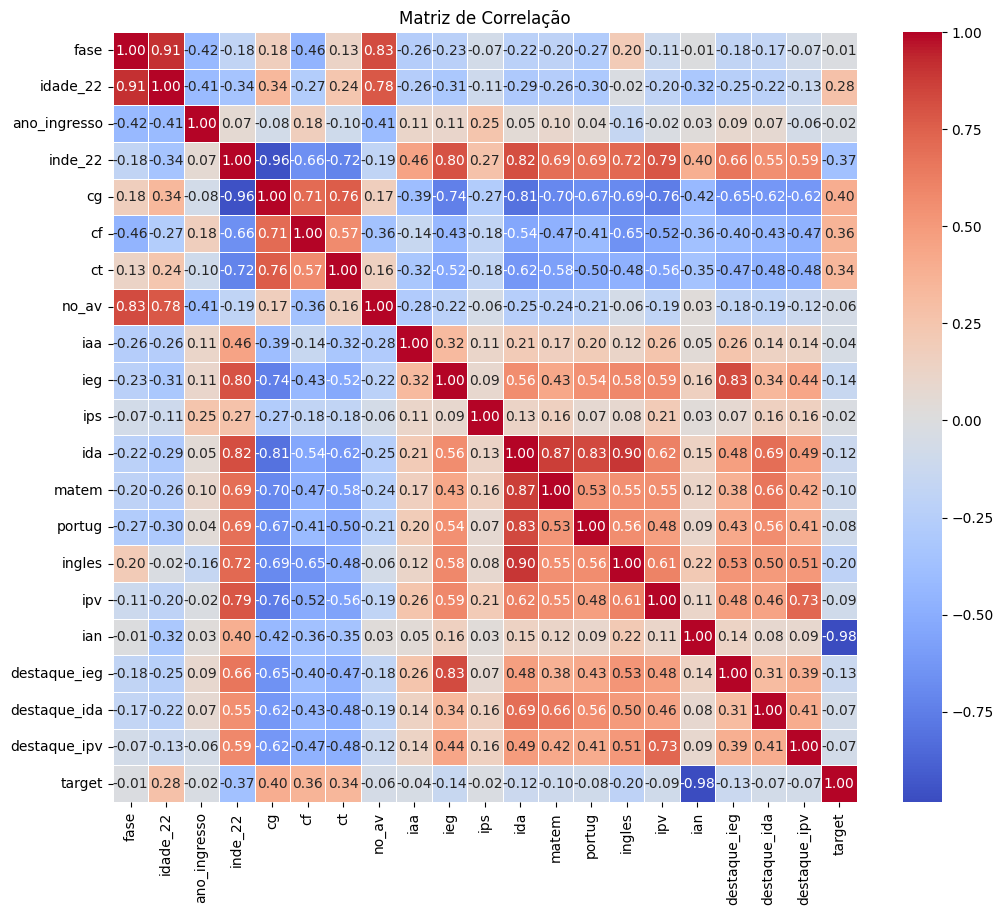

target          1.000000
cg              0.402452
cf              0.362900
ct              0.341963
idade_22        0.277066
fase           -0.013329
ips            -0.022040
ano_ingresso   -0.024654
iaa            -0.039087
no_av          -0.055098
destaque_ida   -0.073680
destaque_ipv   -0.073873
portug         -0.084947
ipv            -0.089052
matem          -0.101140
ida            -0.121880
destaque_ieg   -0.130697
ieg            -0.142086
ingles         -0.202350
inde_22        -0.368921
ian            -0.982845
Name: target, dtype: float64

In [6]:
num_cols = df.select_dtypes(include=["int64","float64"])
corr = num_cols.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de Correlação")
plt.show()
corr["target"].sort_values(ascending=False)

In [7]:
features_selection = [
    # Selecionadas variáveis categóricas com grande diferença de % entre as classes
    "instituicao_de_ensino",
    "pedra_20",
    "pedra_21",
    "pedra_22",
    "indicado",
    "atingiu_pv",
    # Selecionadas variáveis numéricas com correlação maior ou igual a 0.3
    "cg",
    "cf",
    "ct",
    "inde_22",
    # Target
    "target"
]
df = df[features_selection]

# One Hot Encoding
cat_cols = [
    "instituicao_de_ensino",
    "pedra_20",
    "pedra_21",
    "pedra_22",
    "indicado",
    "atingiu_pv"
]
df = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True
)
df.head()

,cg,cf,ct,inde_22,target,instituicao_de_ensino_escola publica,pedra_20_Quartzo,pedra_20_Topázio,pedra_20_Ágata,pedra_21_Quartzo,pedra_21_Topázio,pedra_21_Ágata,pedra_22_Quartzo,pedra_22_Topázio,pedra_22_Ágata,indicado_Sim,atingiu_pv_Sim
0,753,18,10,5.783,1,True,False,False,False,False,False,False,True,False,False,True,False
1,469,8,3,7.055,0,False,False,False,False,False,False,False,False,False,False,False,False
2,629,13,6,6.591,0,False,False,False,False,False,False,False,False,False,True,False,False
3,731,15,7,5.951,0,False,False,False,False,False,False,False,True,False,False,False,False
4,344,6,2,7.427,0,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
# Verificar desbalanceamento do target na base de dados
df['target'].value_counts()

target
1    601
0    259
Name: count, dtype: int64


===== Modelo: RandomForest =====
Acurácia: 0.715
Precision: 0.775
Recall: 0.833
F1-score: 0.803
ROC AUC: 0.701

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.44      0.48        52
           1       0.78      0.83      0.80       120

    accuracy                           0.72       172
   macro avg       0.66      0.64      0.64       172
weighted avg       0.70      0.72      0.71       172



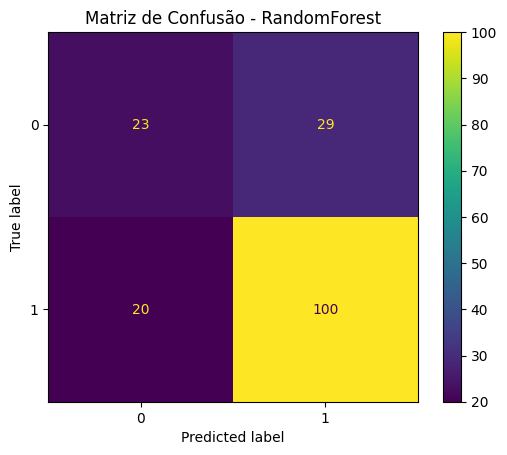


===== Modelo: LogisticRegression =====
Acurácia: 0.692
Precision: 0.802
Recall: 0.742
F1-score: 0.771
ROC AUC: 0.741

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.58      0.53        52
           1       0.80      0.74      0.77       120

    accuracy                           0.69       172
   macro avg       0.65      0.66      0.65       172
weighted avg       0.71      0.69      0.70       172



d:\FIAP\Pos\datathon\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


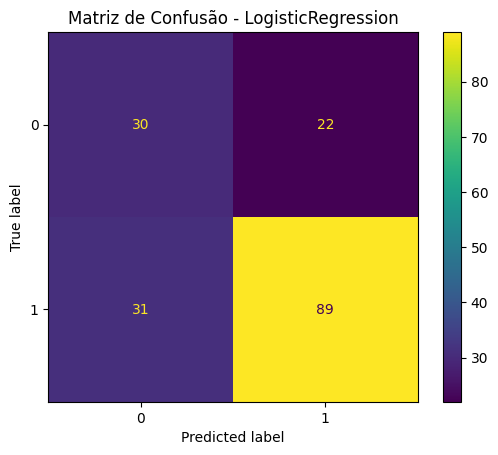


===== Modelo: XGBoost =====
Acurácia: 0.744
Precision: 0.802
Recall: 0.842
F1-score: 0.821
ROC AUC: 0.742

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.52      0.55        52
           1       0.80      0.84      0.82       120

    accuracy                           0.74       172
   macro avg       0.69      0.68      0.69       172
weighted avg       0.74      0.74      0.74       172



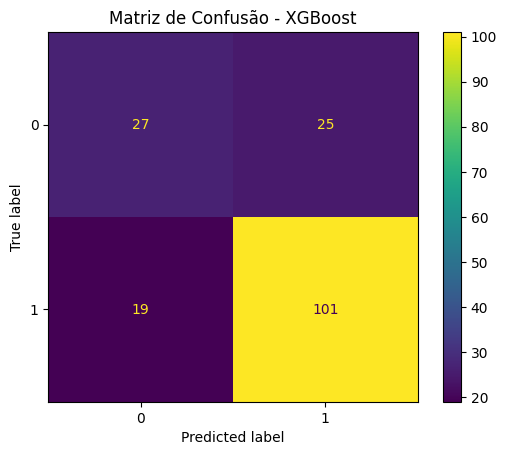

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

features = df.columns.tolist()
features.remove("target")
# Separar features, treino e teste
X = df[features]
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Oversample da classe 0
train = pd.concat([X_train, y_train], axis=1)

class_0 = train[train.target == 0]
class_1 = train[train.target == 1]

class_0_over = resample(
    class_0,
    replace=True,
    n_samples=len(class_1),
    random_state=42
)

train_bal = pd.concat([class_0_over, class_1])

X_train_bal = train_bal[features]
y_train_bal = train_bal["target"]

# Treinar modelos e avaliar
models = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "XGBoost": XGBClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss"
    )
}

for name, model in models.items():

    model.fit(X_train_bal, y_train_bal)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\n===== Modelo: {name} =====")

    # métricas principais
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    print(f"Acurácia: {acc:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-score: {f1:.3f}")
    print(f"ROC AUC: {roc:.3f}")

    # relatório completo
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()

    plt.title(f"Matriz de Confusão - {name}")
    plt.show()

target
0    481
1    481
Name: count, dtype: int64

Modelo: RandomForest
Threshold equilibrado: 0.551
Acurácia: 0.733
Precision: 0.808
Recall: 0.808
F1-score: 0.808
ROC AUC: 0.729

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.56      0.56        52
           1       0.81      0.81      0.81       120

    accuracy                           0.73       172
   macro avg       0.68      0.68      0.68       172
weighted avg       0.73      0.73      0.73       172



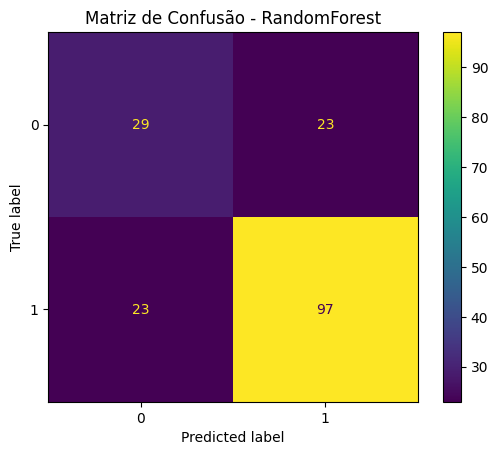


Modelo: LogisticRegression
Threshold equilibrado: 0.439
Acurácia: 0.709
Precision: 0.792
Recall: 0.792
F1-score: 0.792
ROC AUC: 0.739

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.52      0.52        52
           1       0.79      0.79      0.79       120

    accuracy                           0.71       172
   macro avg       0.66      0.66      0.66       172
weighted avg       0.71      0.71      0.71       172



d:\FIAP\Pos\datathon\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


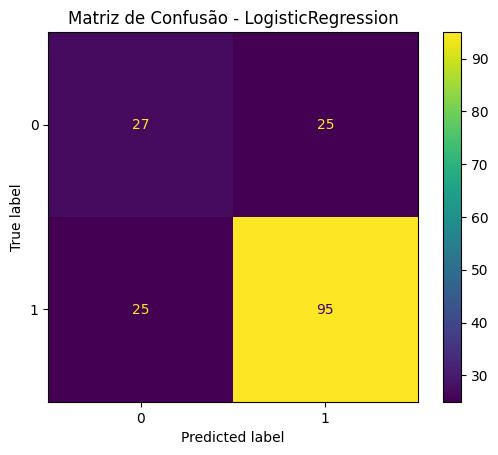


Modelo: XGBoost
Threshold equilibrado: 0.585
Acurácia: 0.721
Precision: 0.800
Recall: 0.800
F1-score: 0.800
ROC AUC: 0.733

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.54      0.54        52
           1       0.80      0.80      0.80       120

    accuracy                           0.72       172
   macro avg       0.67      0.67      0.67       172
weighted avg       0.72      0.72      0.72       172



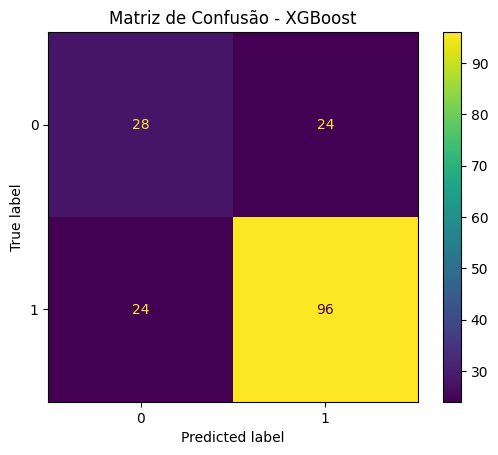

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve
)

# -----------------------------
# Separar features e target
# -----------------------------

features = df.columns.tolist()
features.remove("target")

X = df[features]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# Oversampling
# -----------------------------

train = pd.concat([X_train, y_train], axis=1)

class_0 = train[train.target == 0]
class_1 = train[train.target == 1]

class_0_over = resample(
    class_0,
    replace=True,
    n_samples=len(class_1),
    random_state=42
)

train_bal = pd.concat([class_0_over, class_1])

X_train_bal = train_bal[features]
y_train_bal = train_bal["target"]

# -----------------------------
# Função para threshold equilibrado
# -----------------------------

def find_balanced_threshold(y_true, y_prob):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    diff = np.abs(precisions - recalls)
    best_index = np.argmin(diff)

    return thresholds[best_index]

# -----------------------------
# Modelos
# -----------------------------

models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42
    ),

    "LogisticRegression": LogisticRegression(
        max_iter=2000
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss"
    )
}

# -----------------------------
# Treinar e avaliar
# -----------------------------

for name, model in models.items():

    model.fit(X_train_bal, y_train_bal)

    y_prob = model.predict_proba(X_test)[:, 1]

    best_threshold = find_balanced_threshold(y_test, y_prob)

    y_pred = (y_prob >= best_threshold).astype(int)

    print("\n==============================")
    print(f"Modelo: {name}")
    print("==============================")

    print(f"Threshold equilibrado: {best_threshold:.3f}")

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    print(f"Acurácia: {acc:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-score: {f1:.3f}")
    print(f"ROC AUC: {roc:.3f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(cm)
    disp.plot()

    plt.title(f"Matriz de Confusão - {name}")
    plt.show()